<a href="https://colab.research.google.com/github/kkinca/ReneWind/blob/main/wind_turbine_failure_prediction_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

In [2]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the Data**

In [ ]:
df = pd.read_csv("Train.csv")
df_test = pd.read_csv("Test.csv")

# **Data Overview**

The initial steps to get an overview of any dataset is to:
- observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- get information about the number of rows and columns in the dataset
- find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- check the statistical summary of the dataset to get an overview of the numerical columns of the data

## Checking the shape of the dataset

In [4]:
# Checking the number of rows and columns in the training data
df.shape

(20000, 41)

In [5]:
# Checking the number of rows and columns in the test data
df_test.shape

(5000, 41)

In [6]:
# create a copy of the training data
data = df.copy()

In [7]:
# create a copy of the testing  data
data_test = df_test.copy()

## Displaying the first few rows of the dataset

In [8]:
# let's view the first 5 rows of the data
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [9]:
#viewing first 5 rows of the test data
data_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


## Checking the data types of the columns in the dataset

In [10]:
# check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

- Converting Target column to float

In [11]:
data['Target'] = data['Target'].astype(float)

Now checking for test data

In [12]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

Converting Target to float

In [13]:
data_test['Target'] = data_test['Target'].astype(float)

## Checking for duplicate values

In [14]:
# check for duplicate values in the data
data.duplicated().sum() # Complete the code to check for duplicate values in the train data

np.int64(0)

## Checking for missing values

In [15]:
# check for missing values in the data
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [16]:
# check for missing values in the test data
data_test.isnull().sum() #

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


## Statistical summary of the dataset

In [17]:
# let's view the statistical summary of the numerical columns in the data
data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,...,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,...,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,...,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,...,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,...,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,...,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,...,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


# **Exploratory Data Analysis**

## Univariate analysis

In [18]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color="blue"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, color="blue"
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Variables V1 to V29

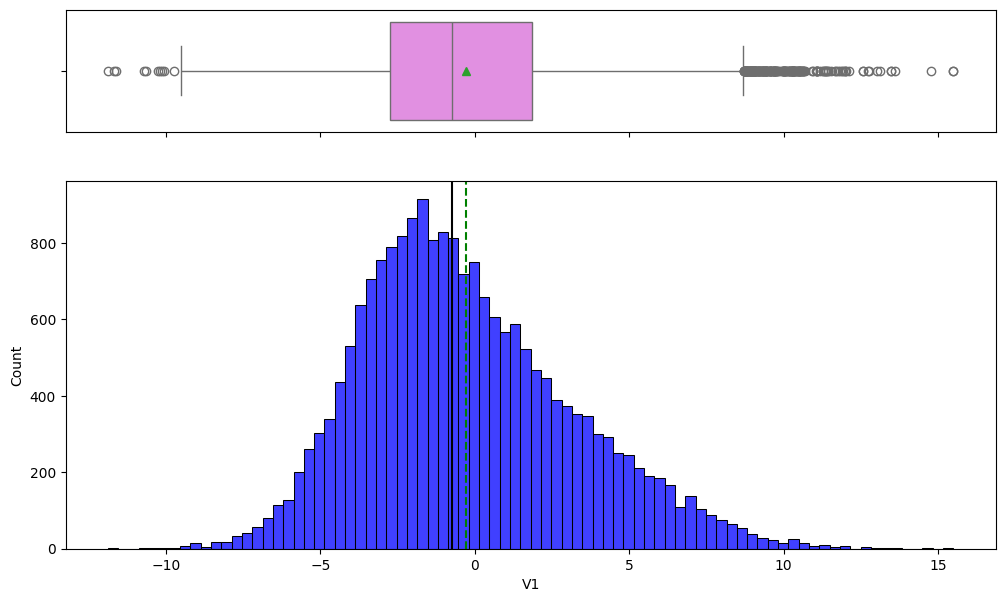

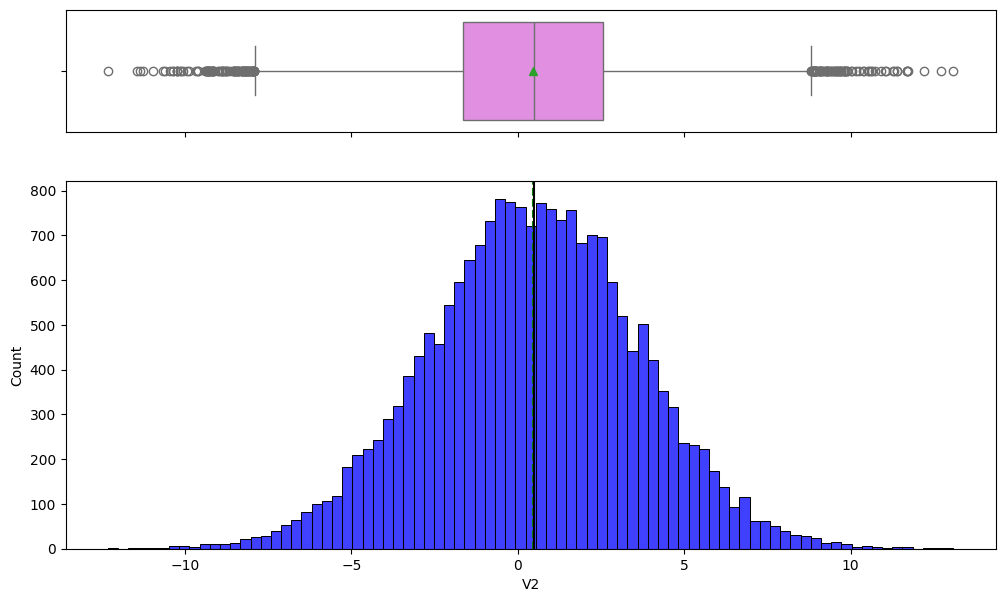

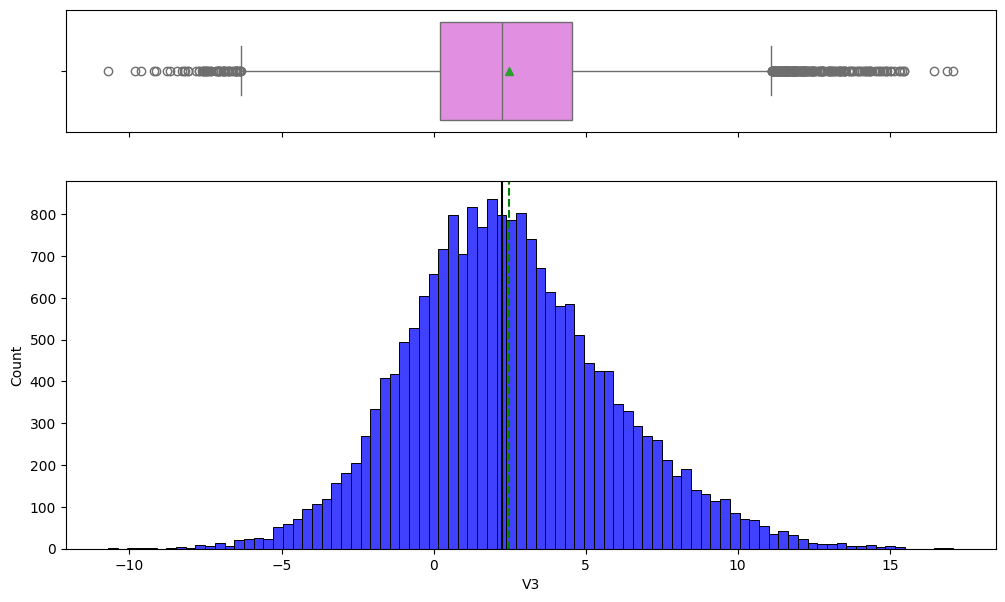

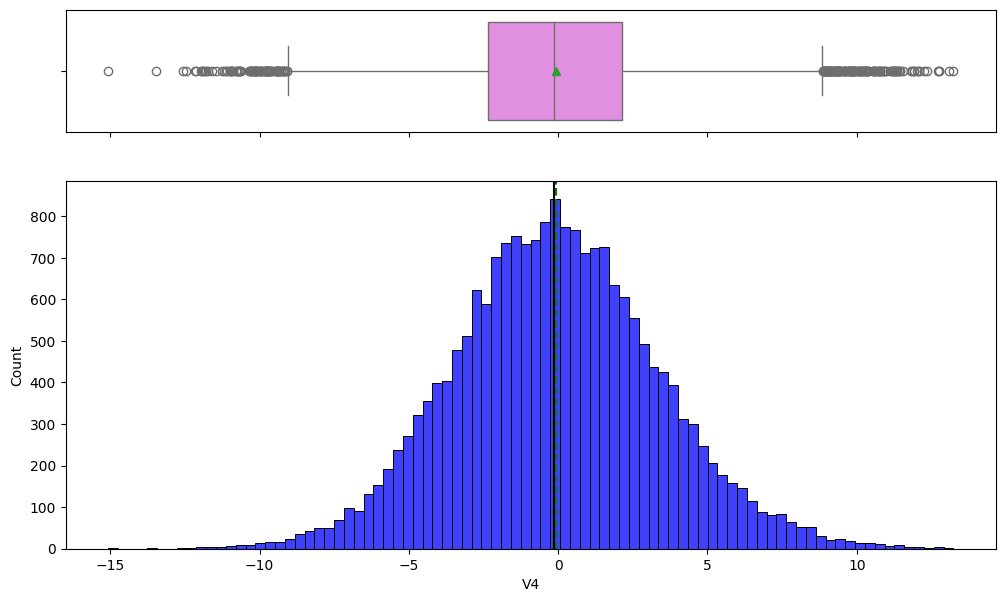

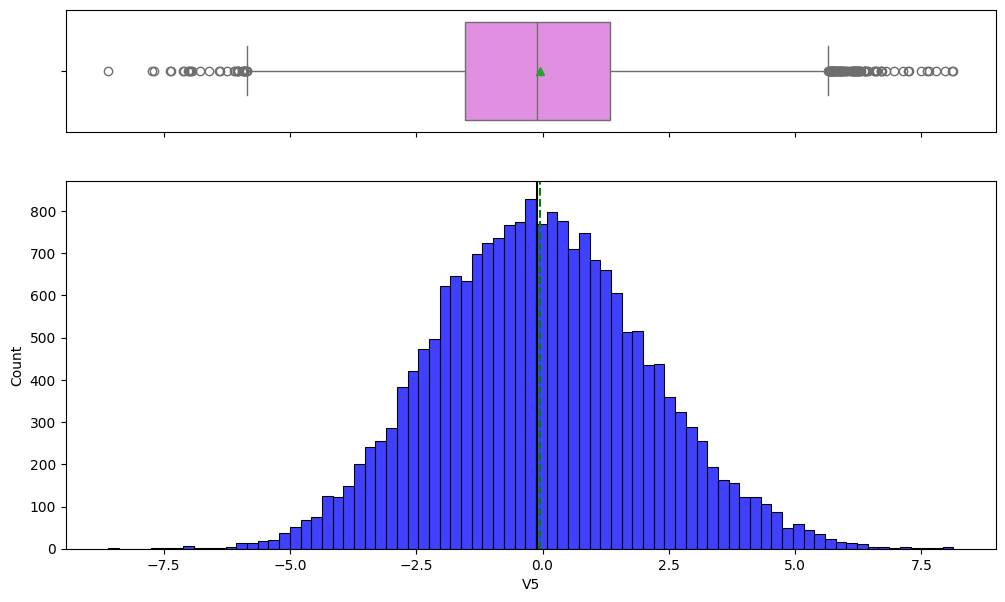

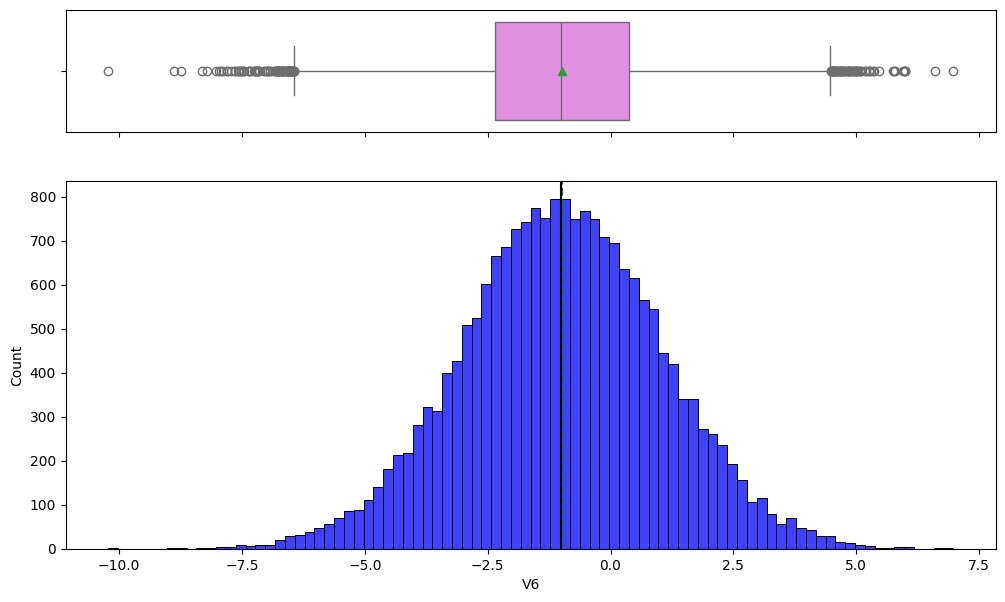

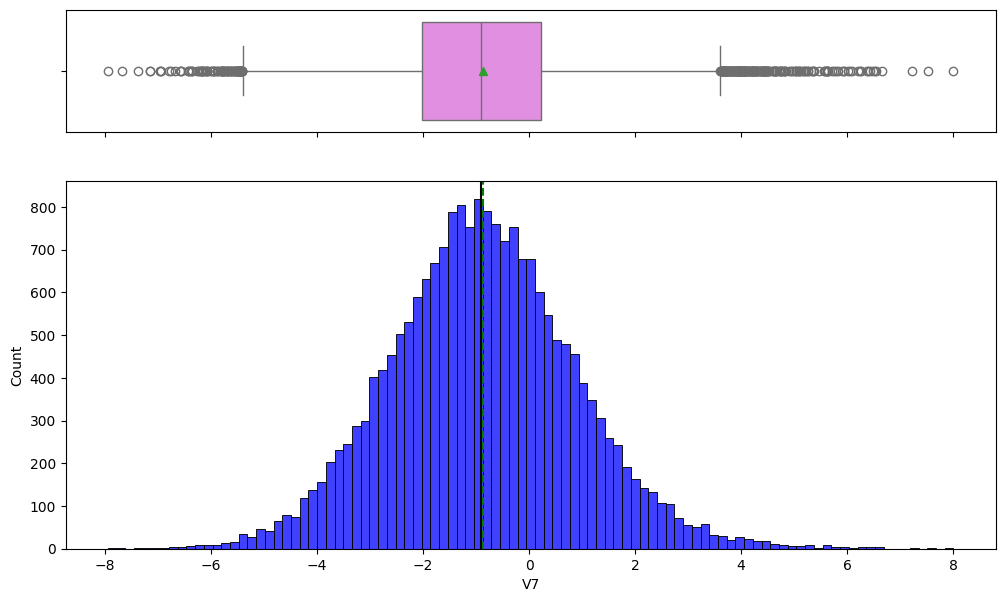

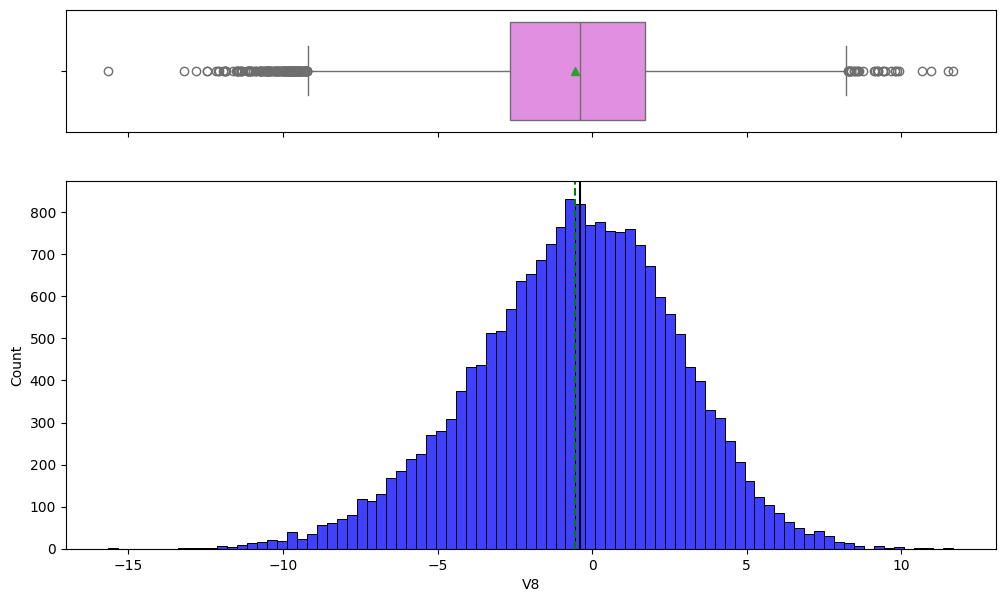

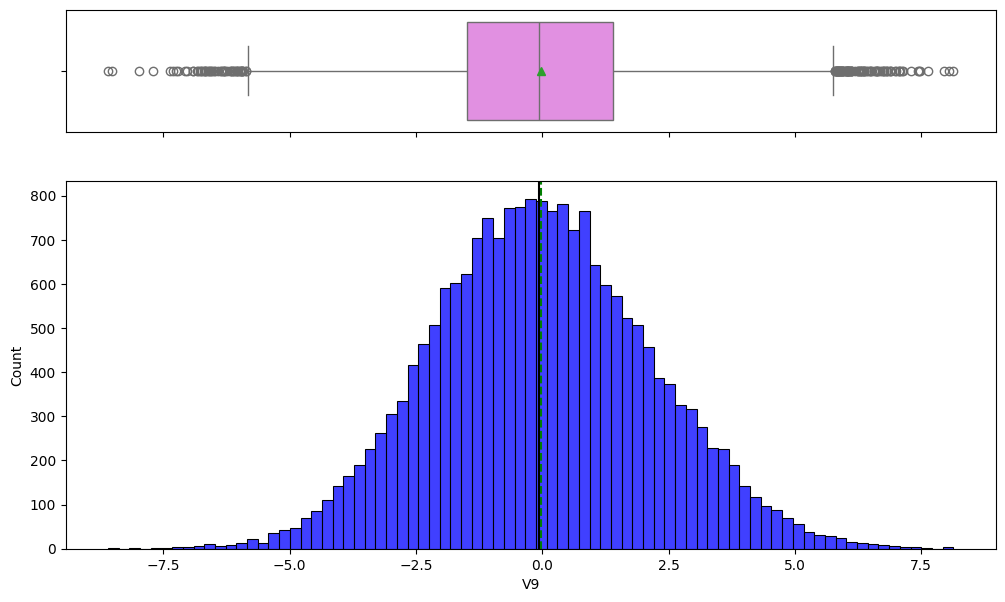

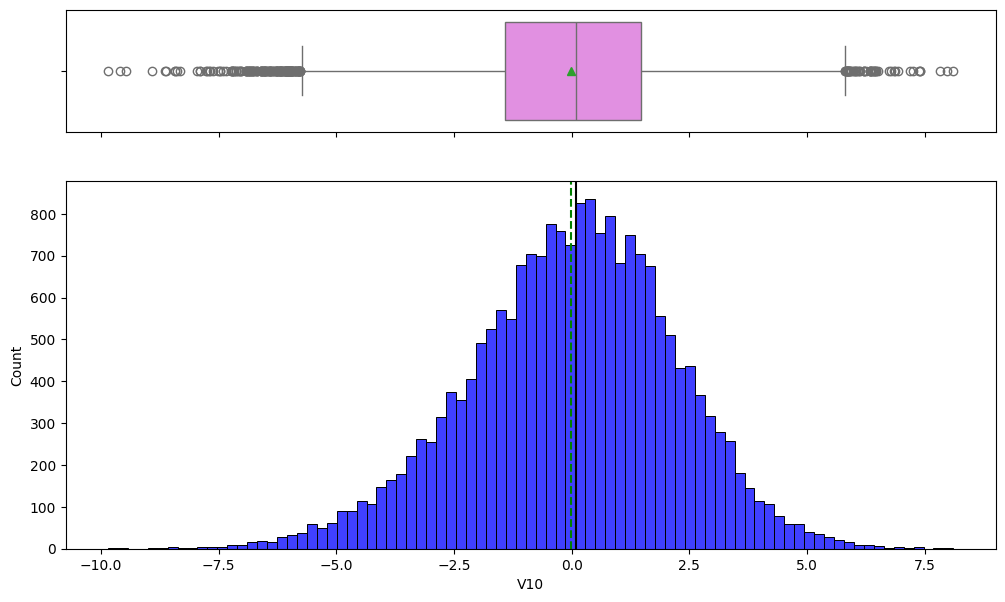

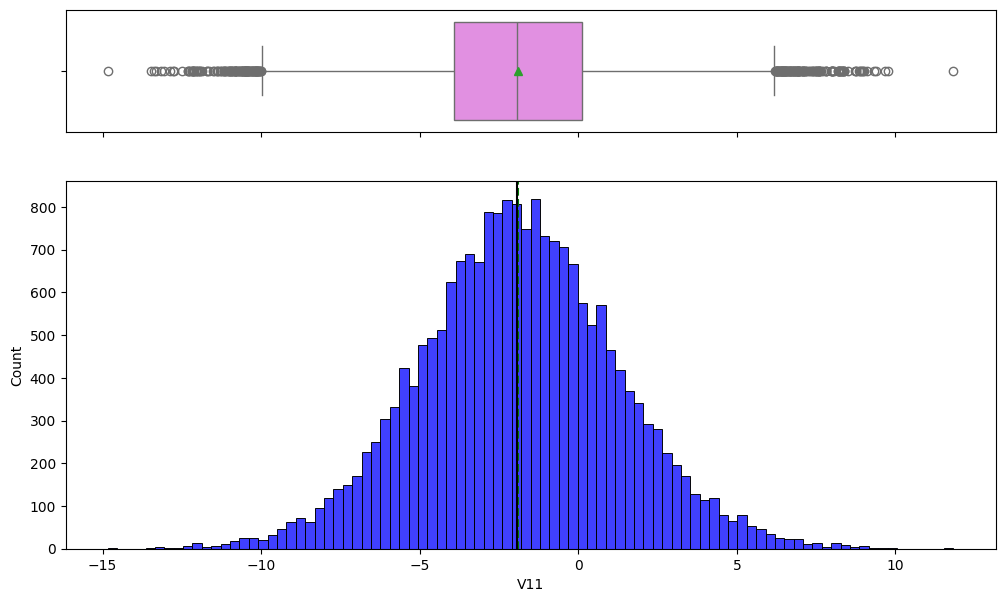

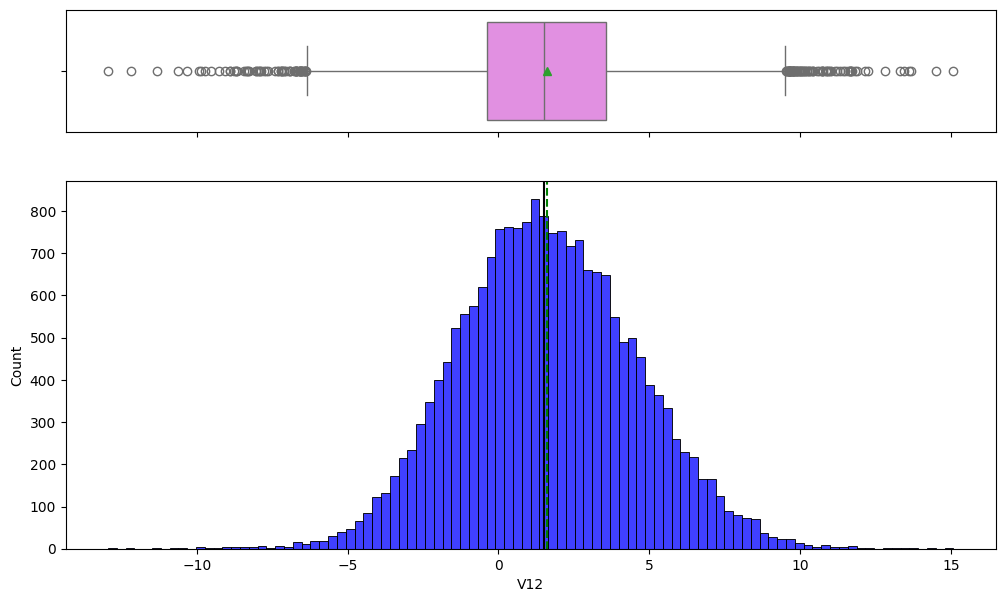

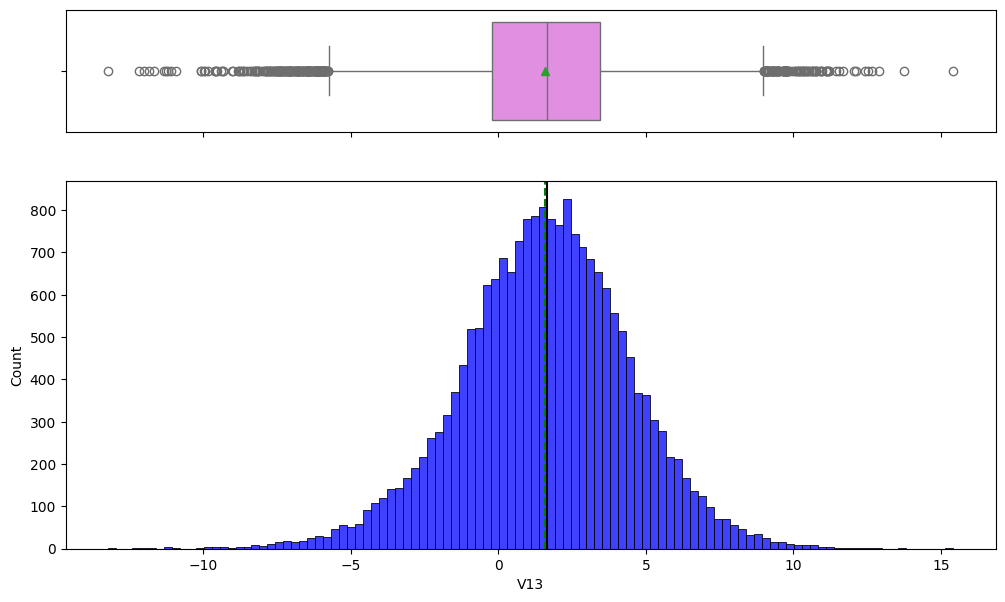

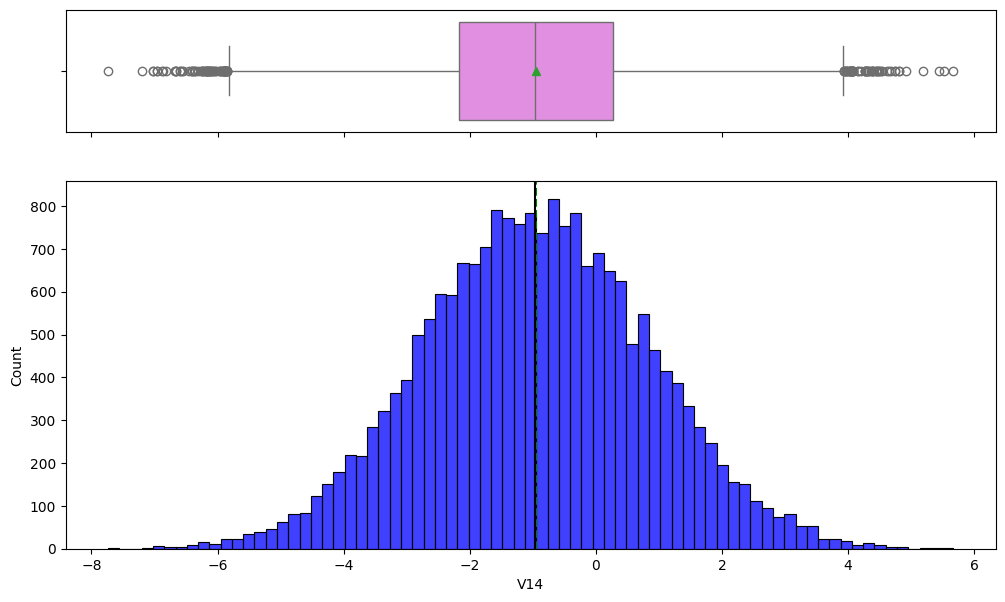

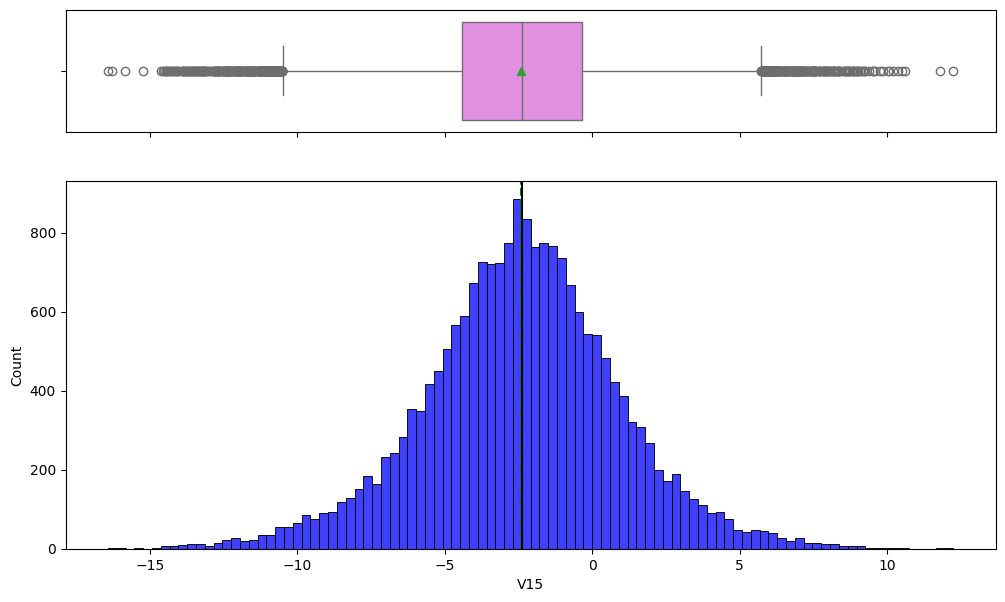

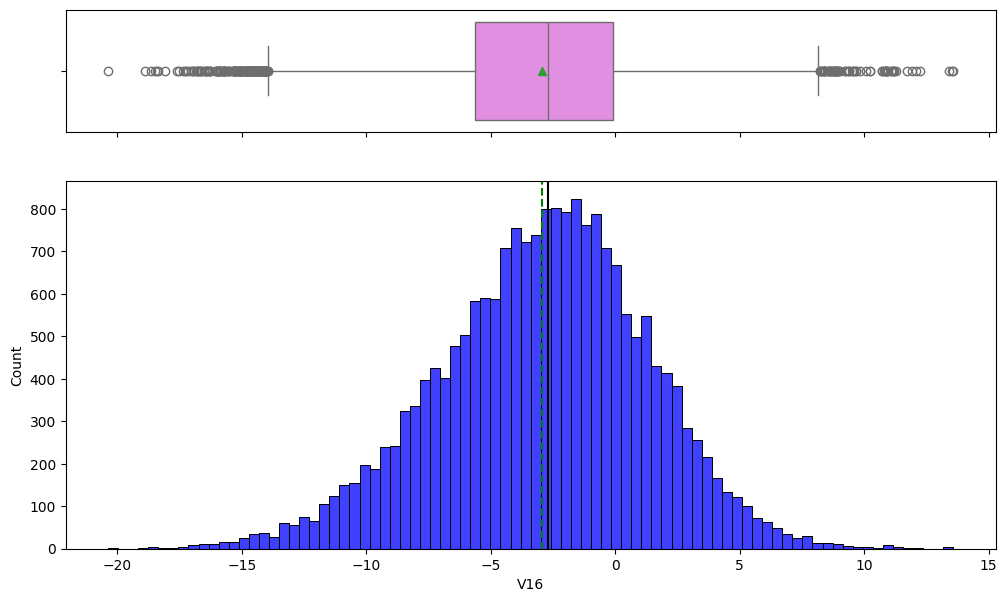

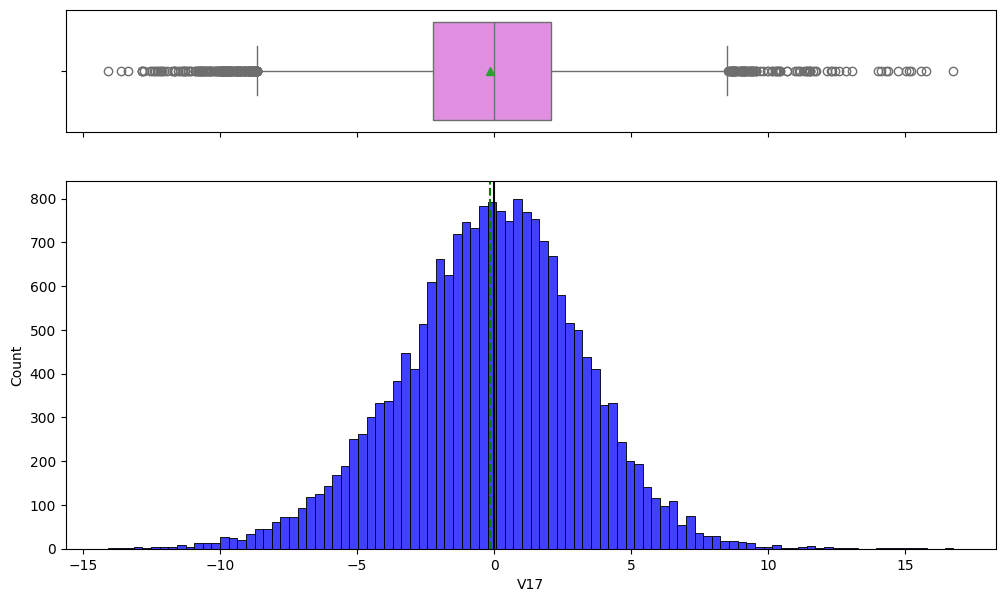

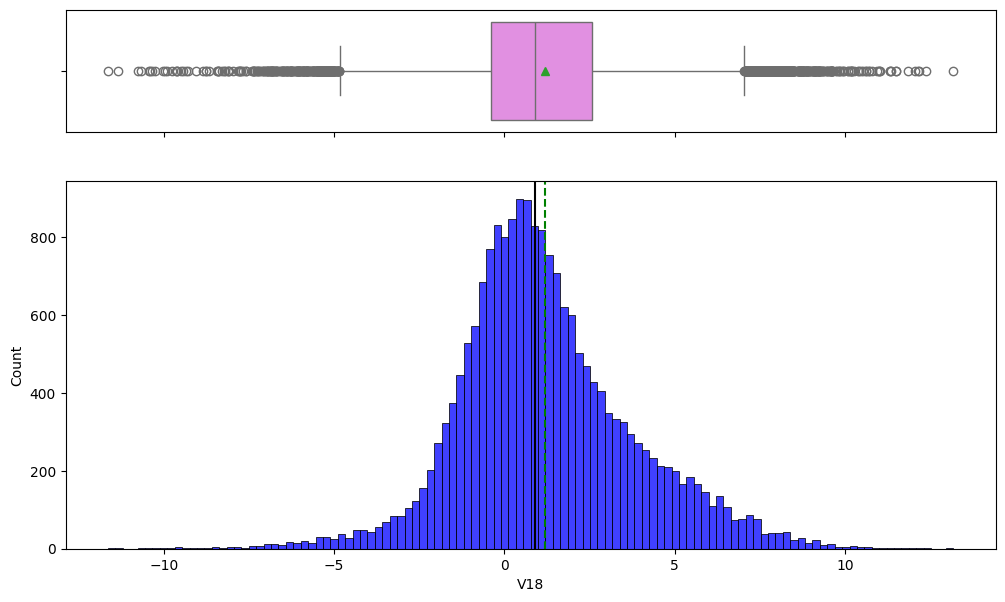

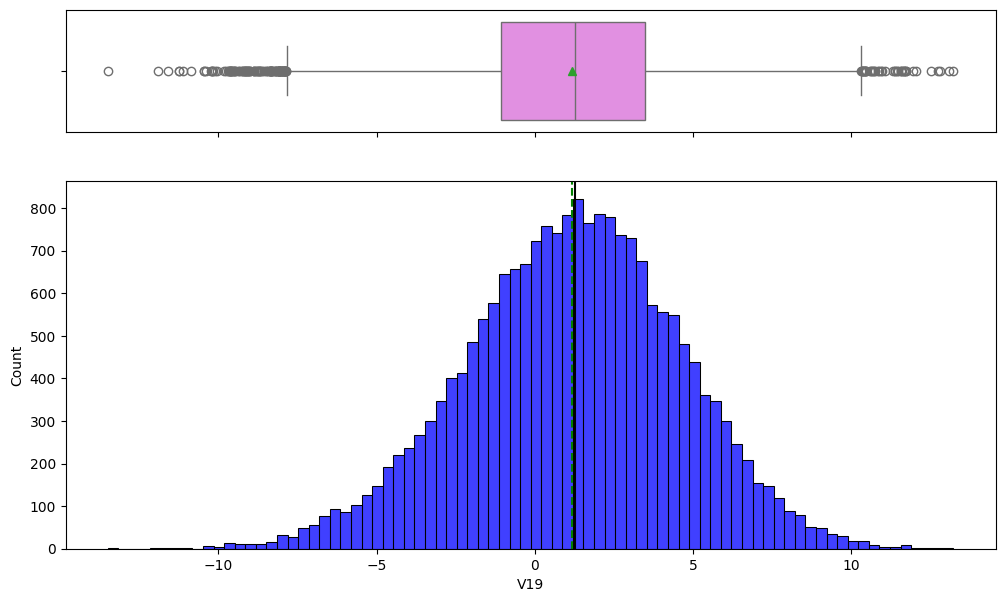

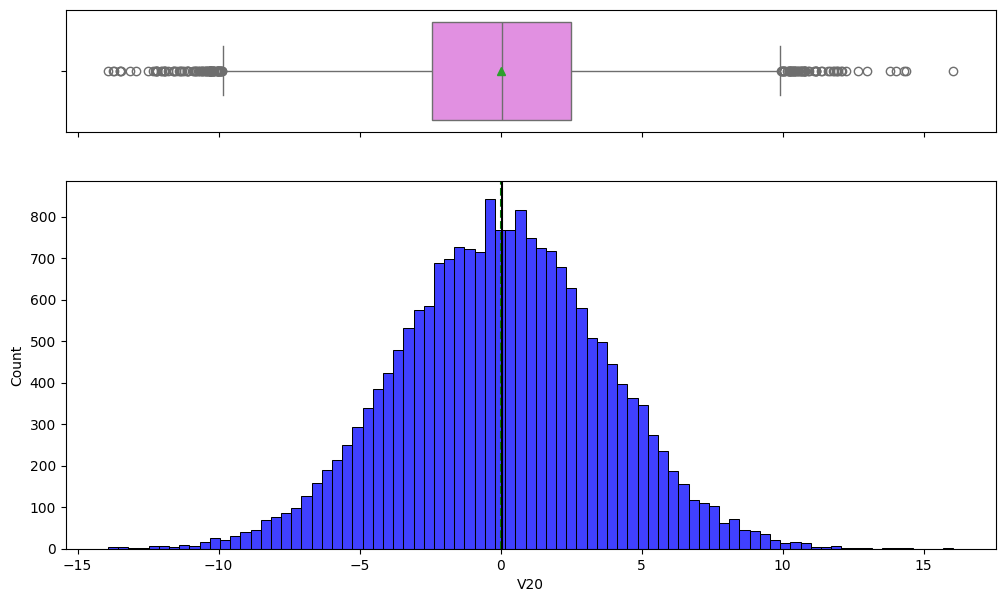

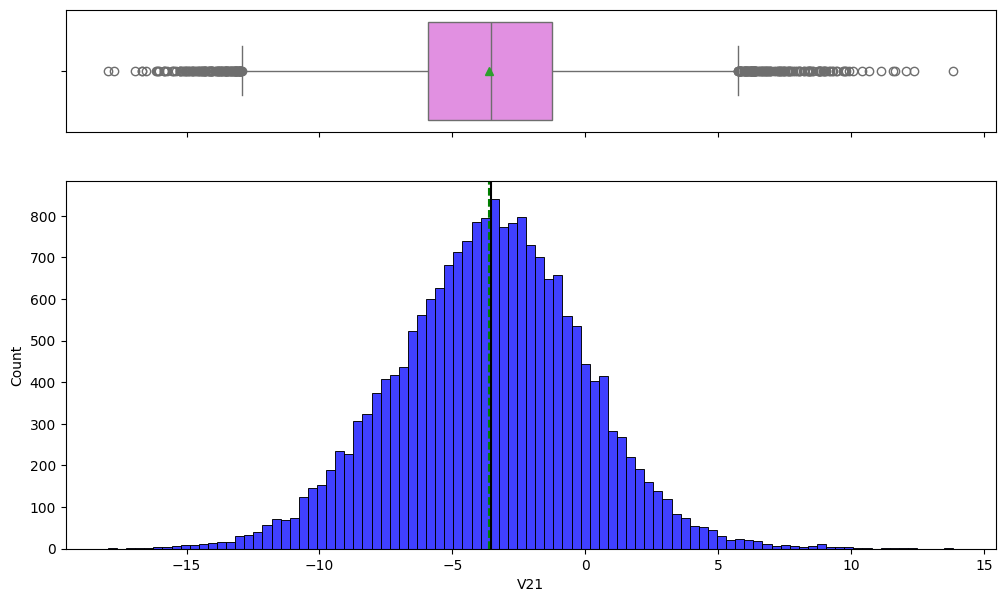

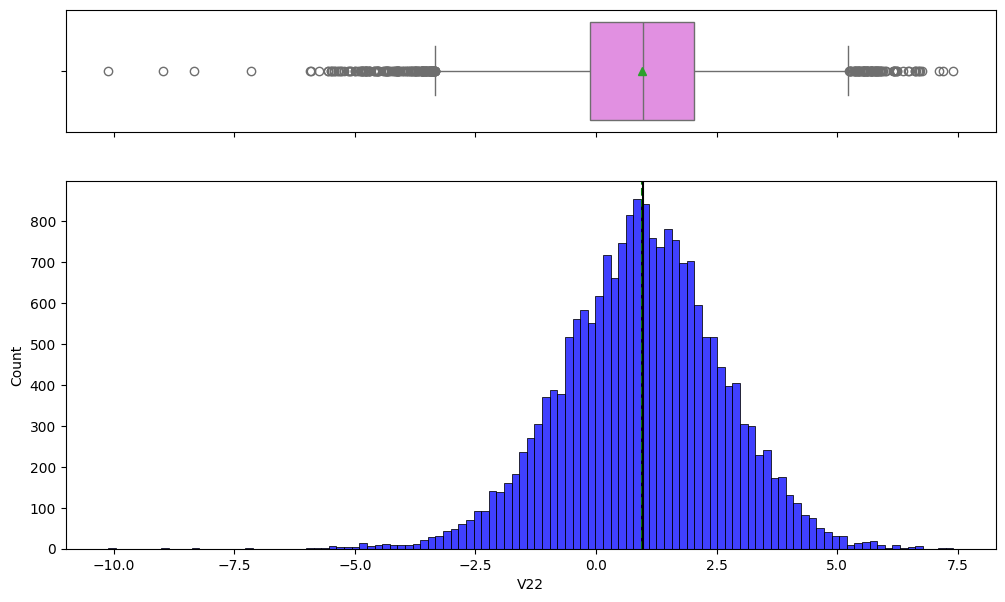

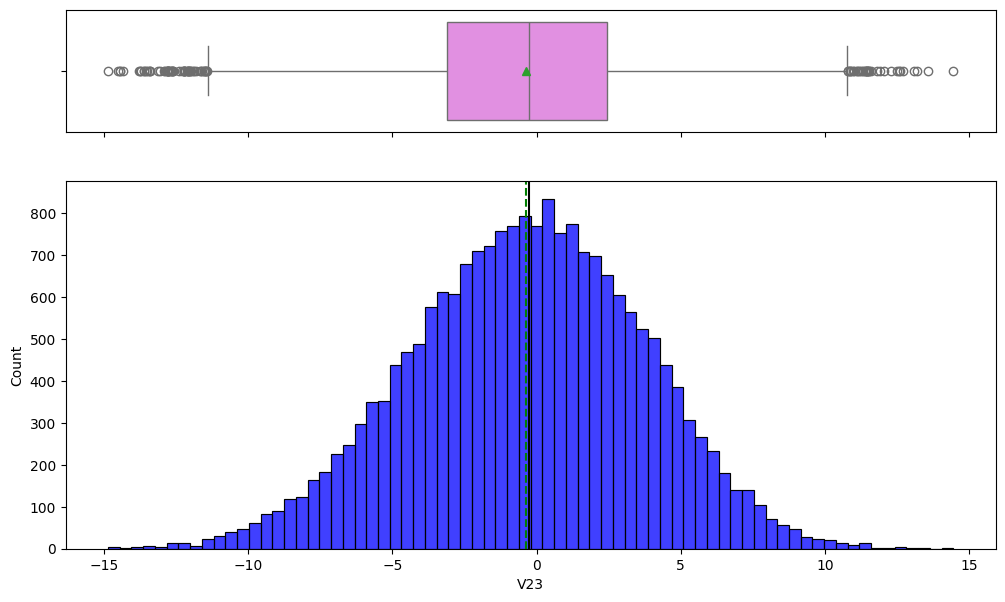

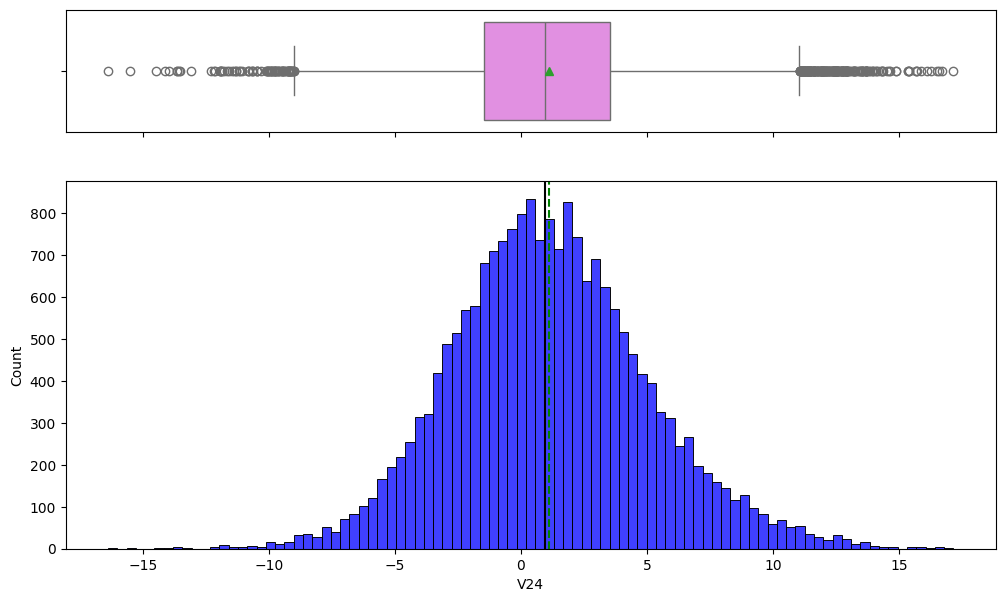

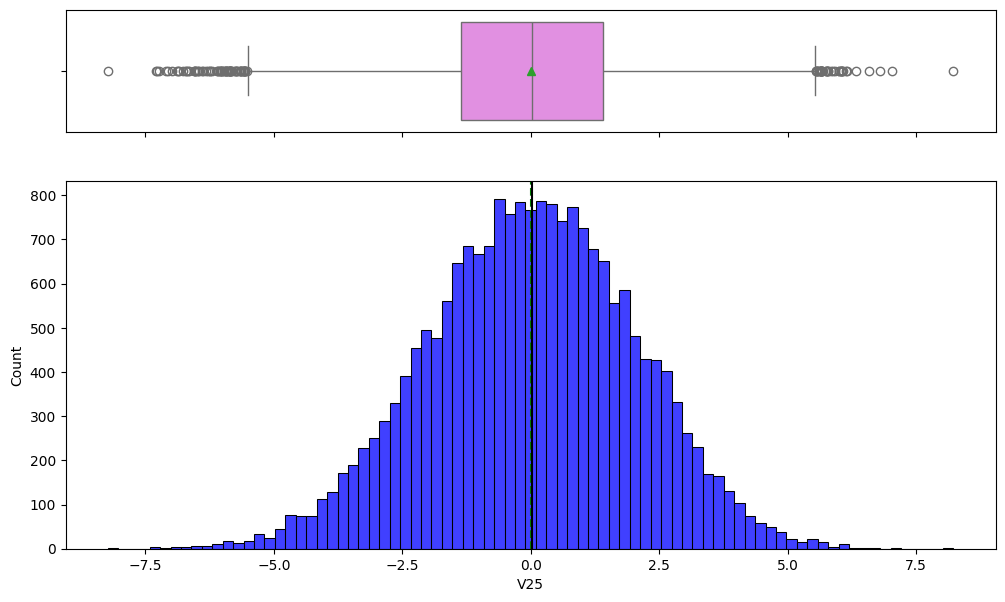

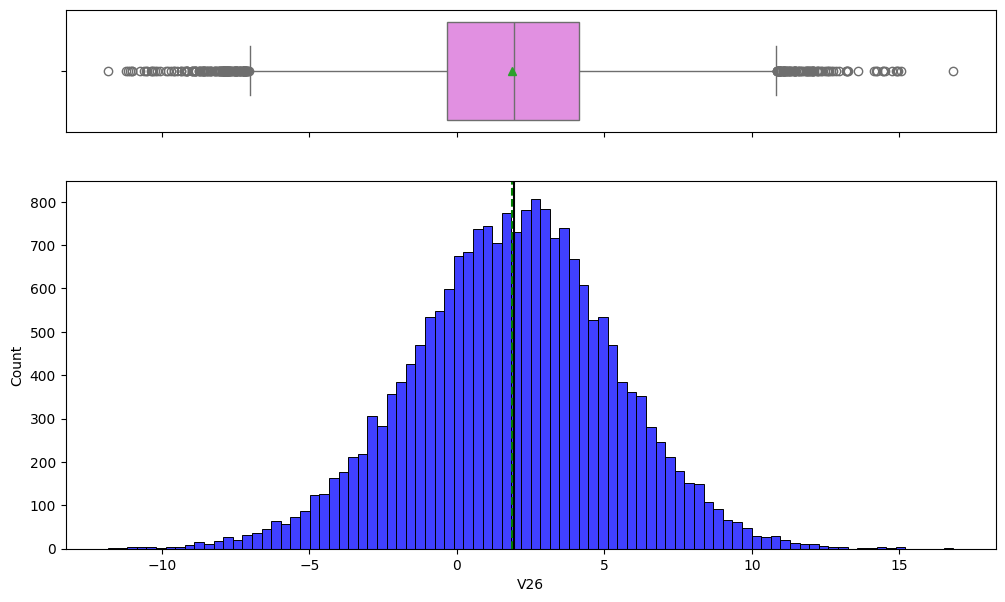

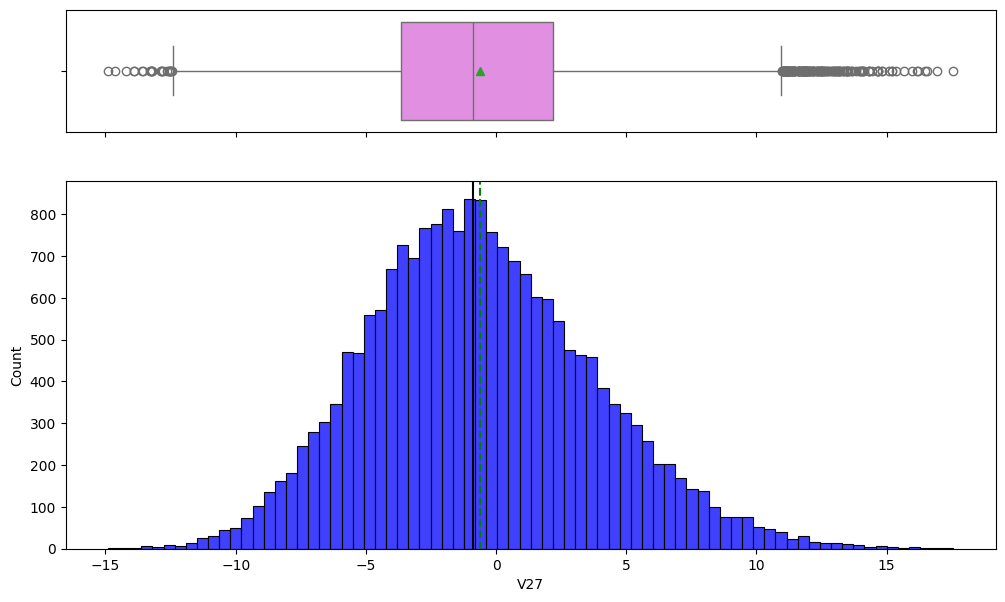

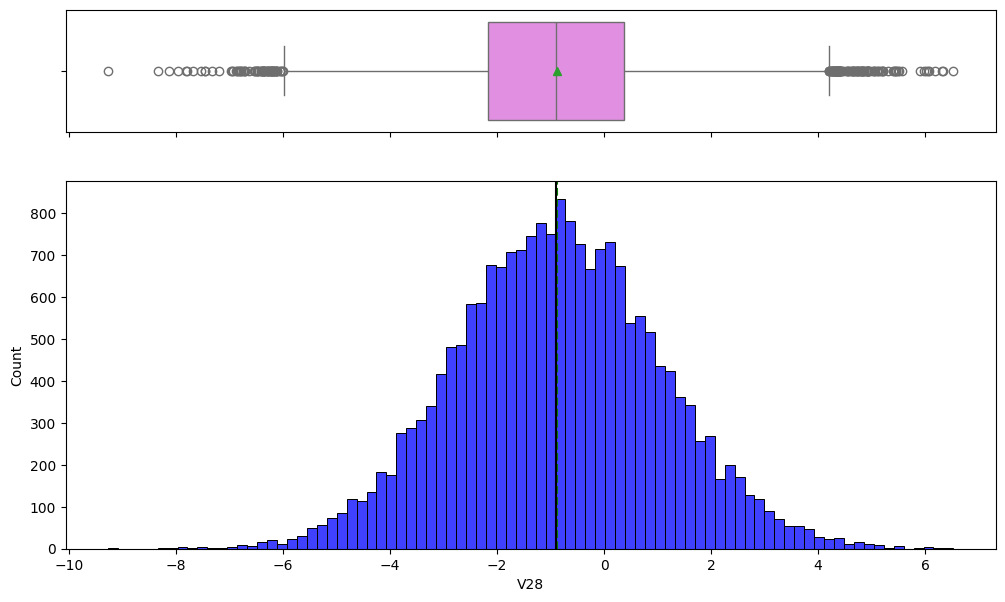

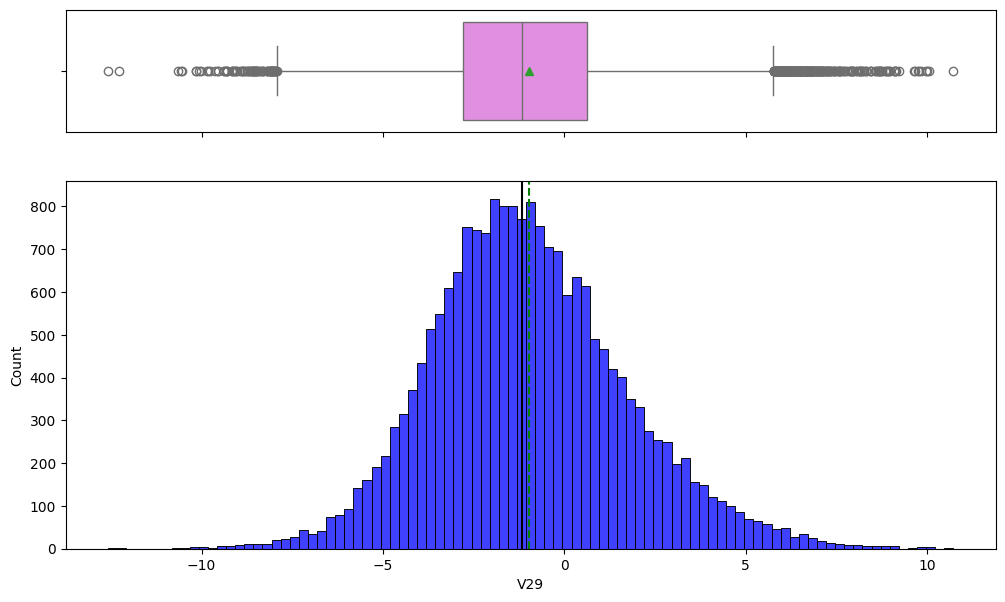

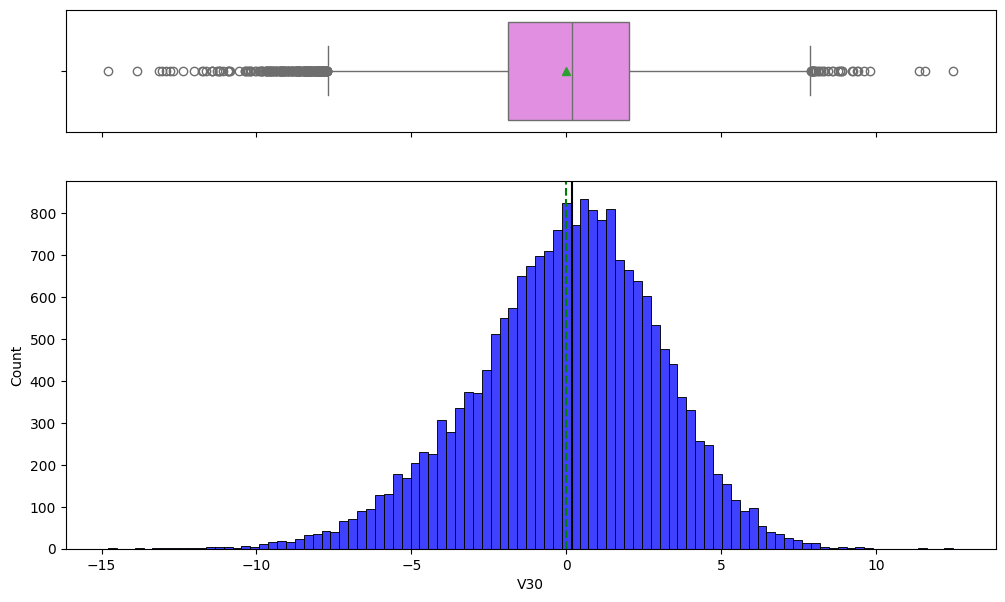

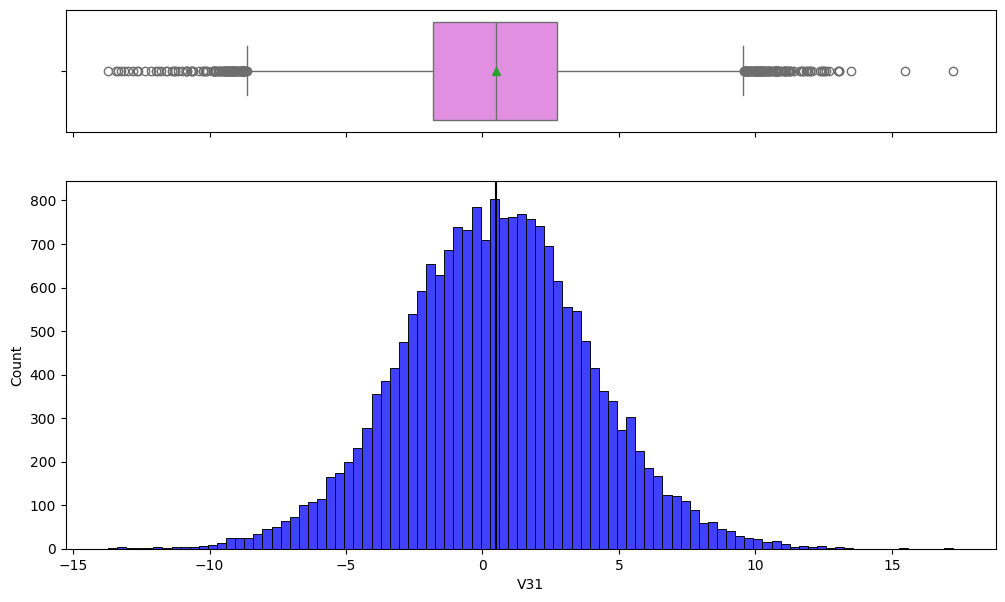

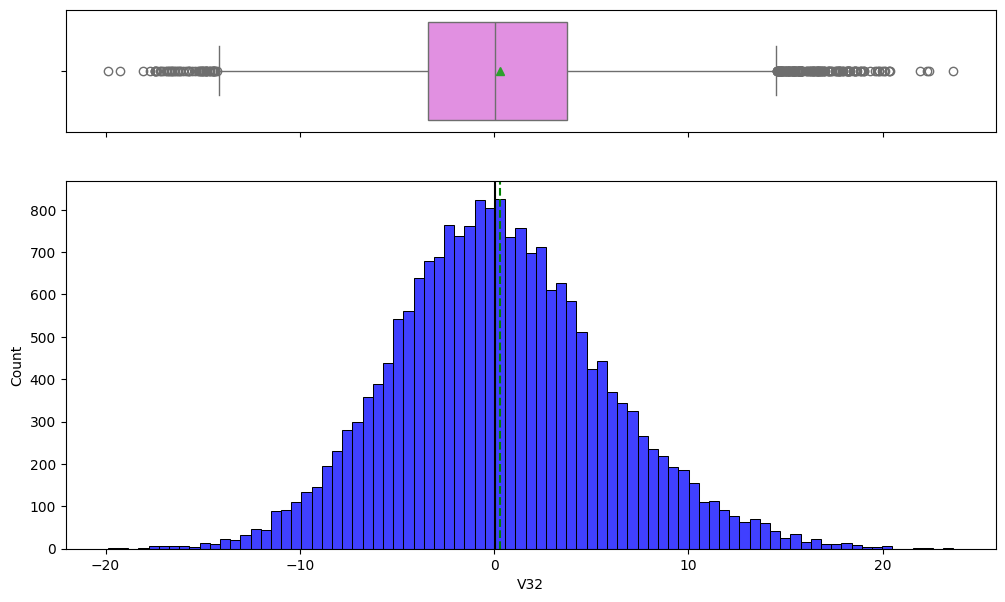

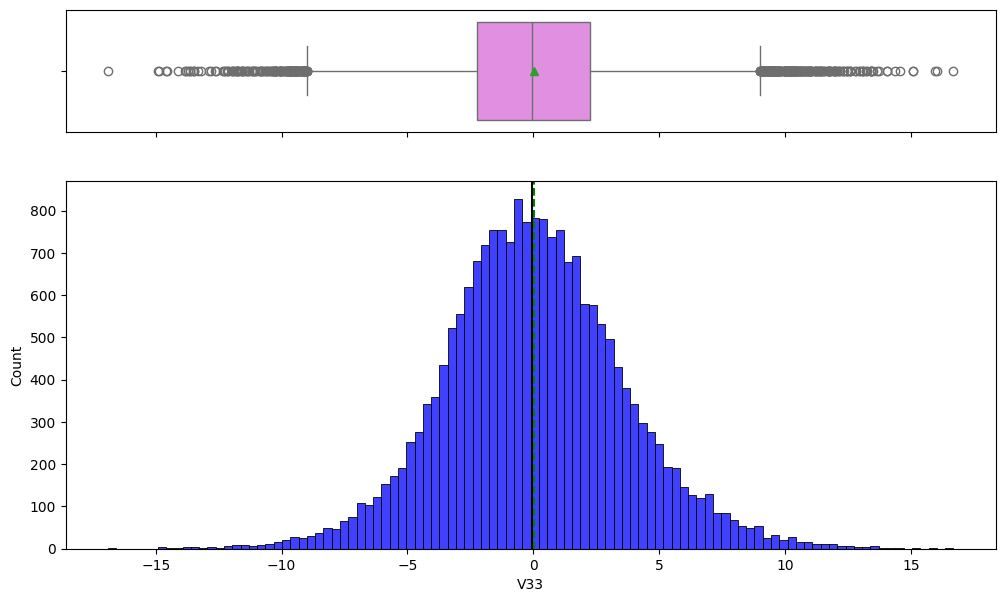

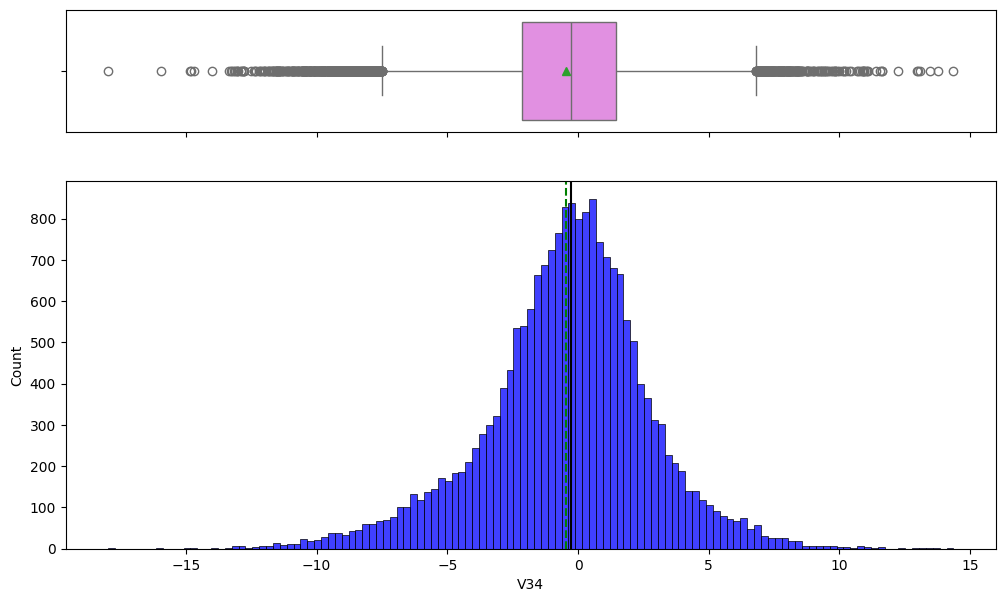

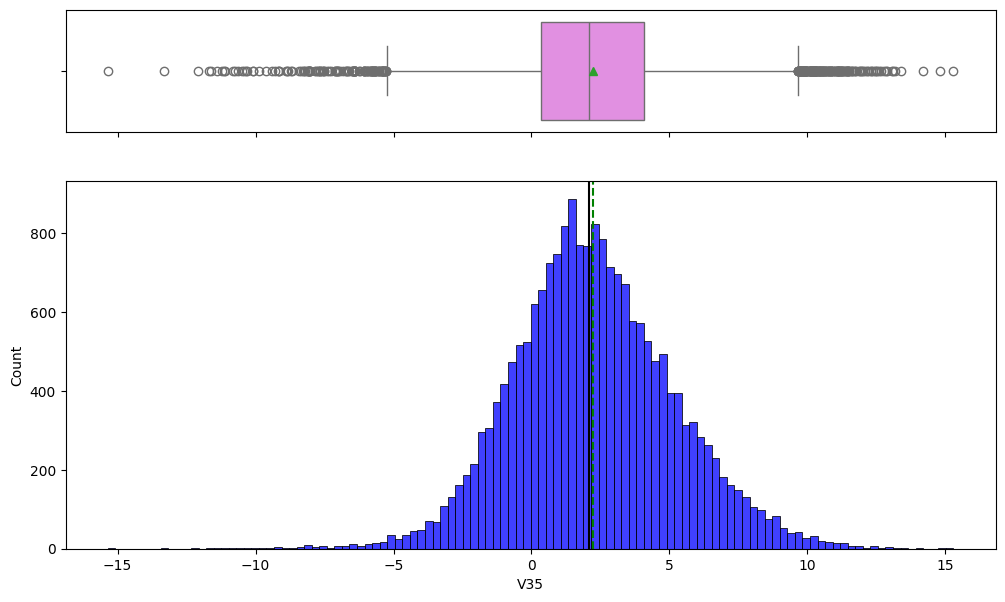

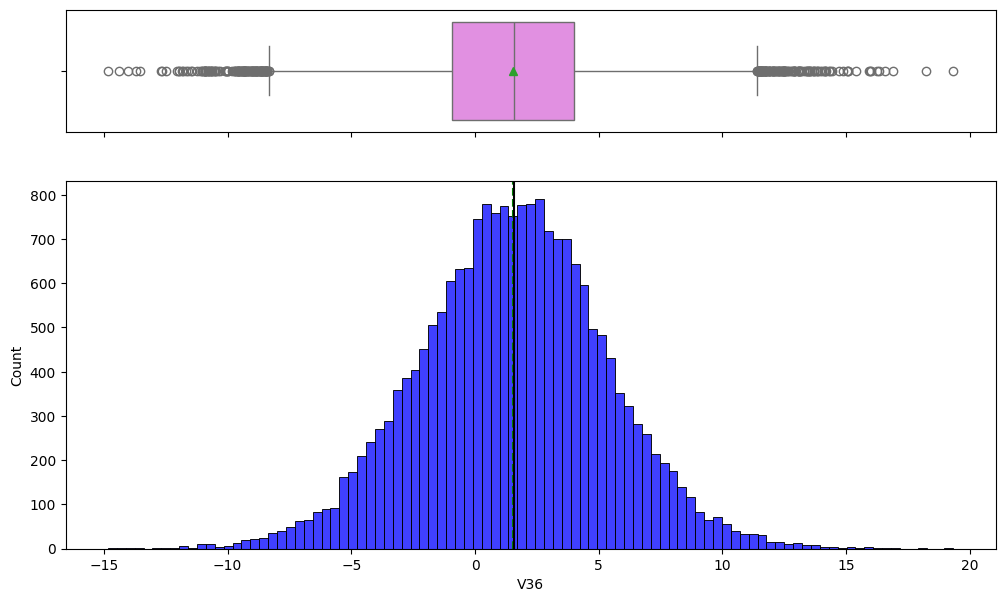

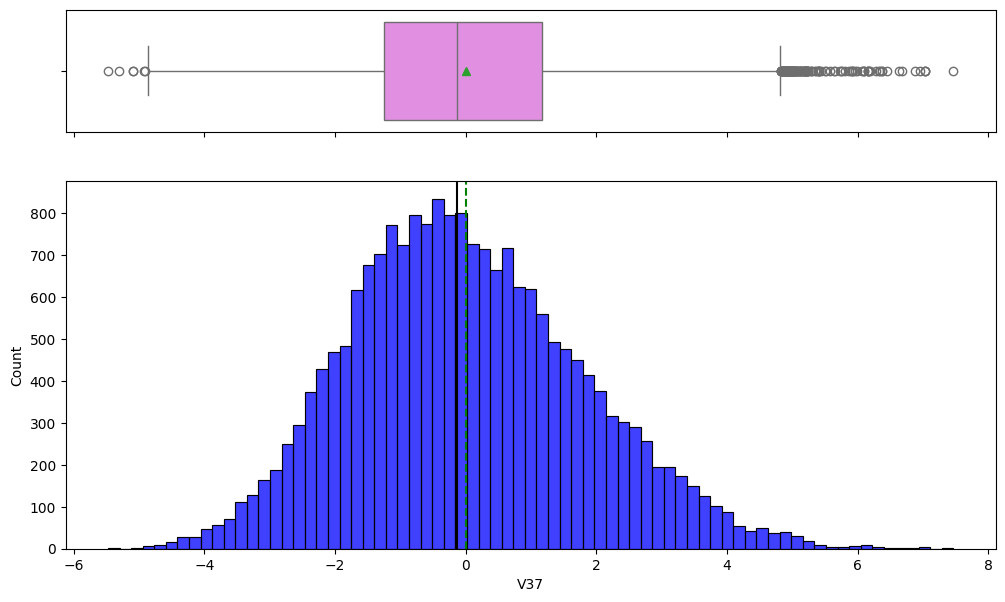

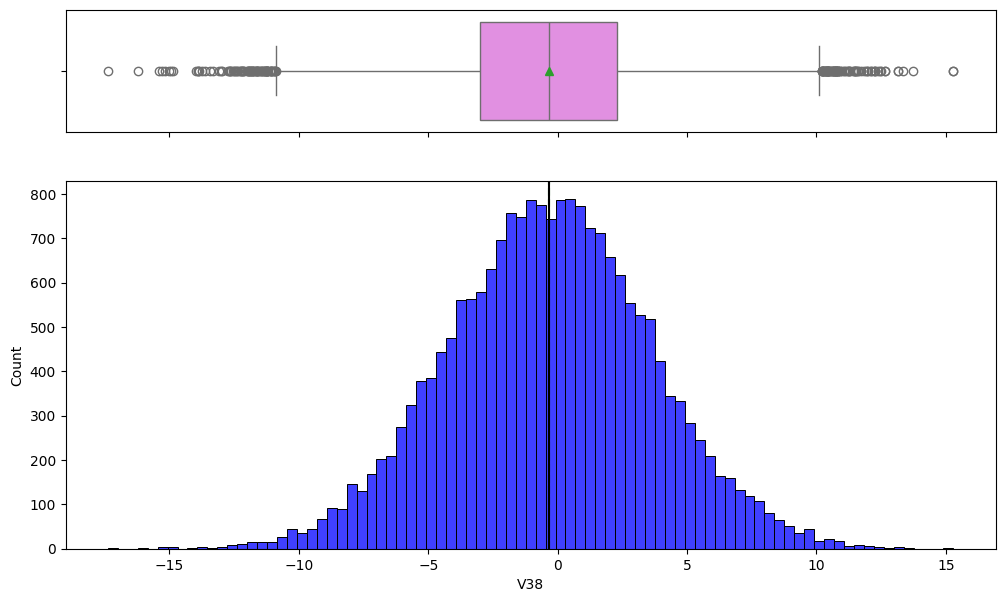

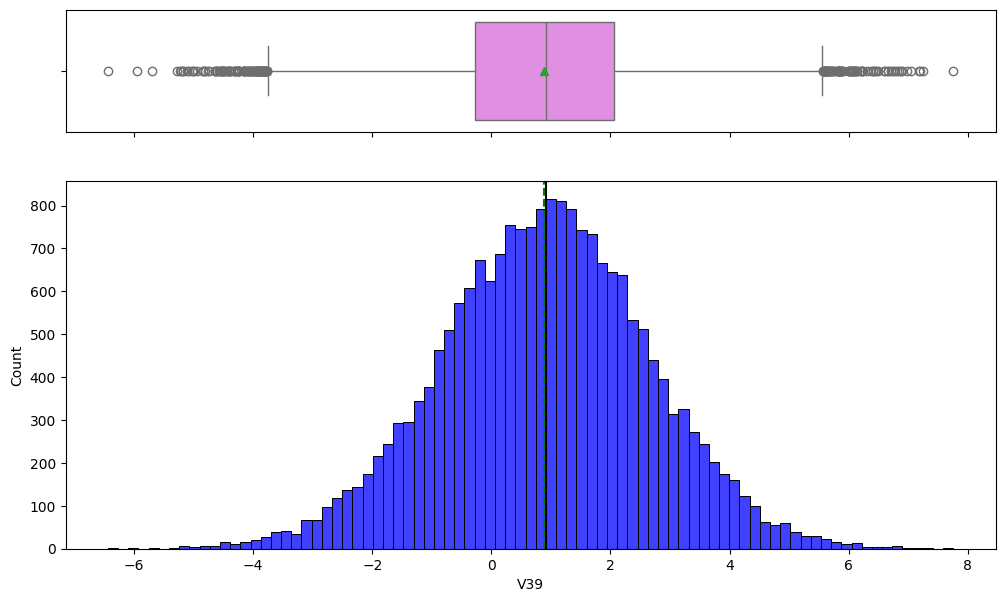

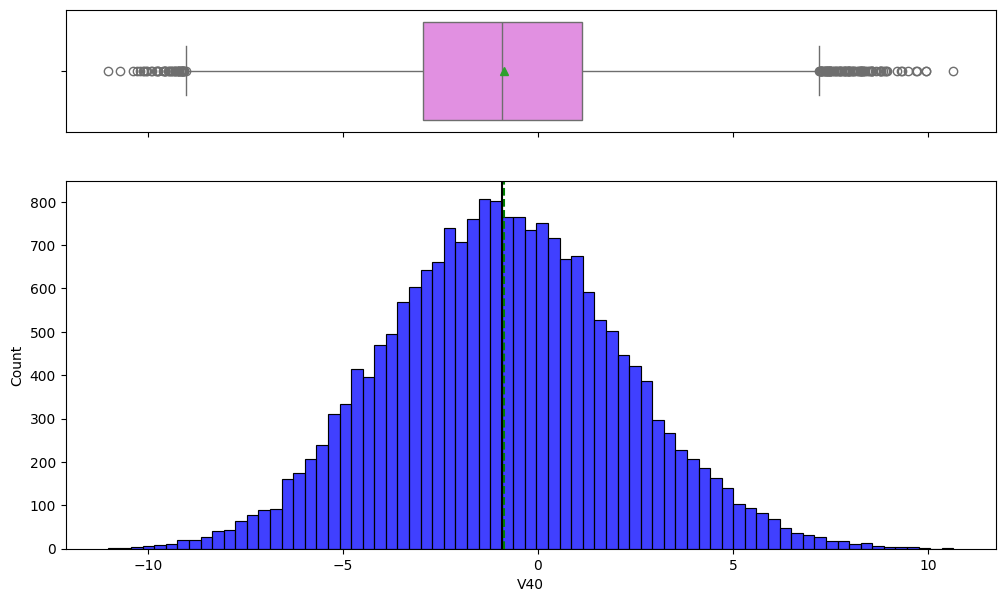

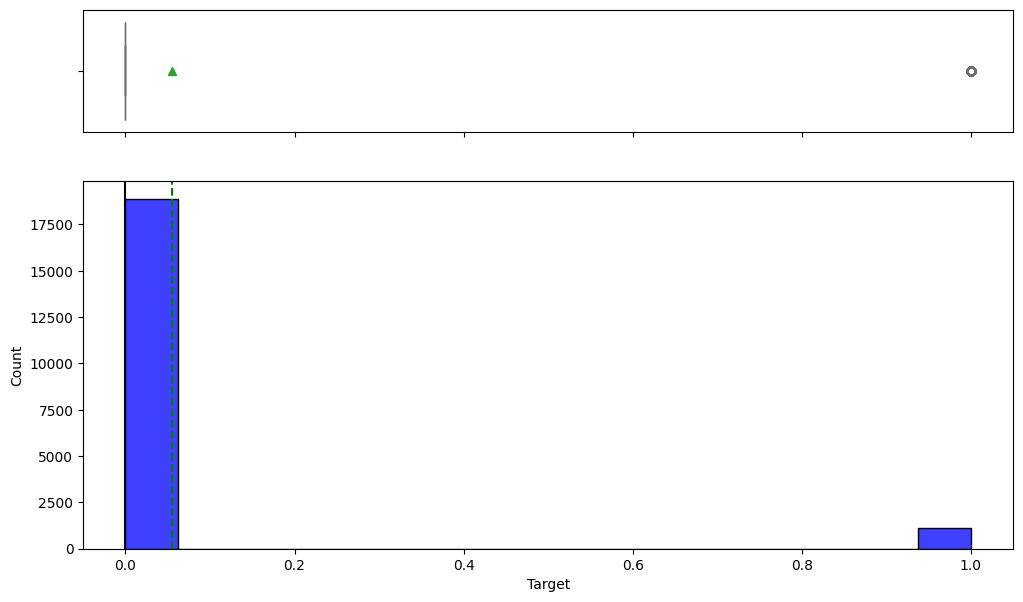

In [19]:
for feature in df.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None)

### Checking the distrubution of Target variable

In [ ]:
# For train data
df["Target"].value_counts(1)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot for training data
sns.barplot(x=np.unique(y_train, return_counts=True)[0], y=np.unique(y_train, return_counts=True)[1], ax=axes[0])
axes[0].set_title('Class Distribution in Training Data')
axes[0].set_xlabel('Class (0: No Failure, 1: Failure)')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Failure', 'Failure'])

# Plot for test data
sns.barplot(x=np.unique(y_test, return_counts=True)[0], y=np.unique(y_test, return_counts=True)[1], ax=axes[1])
axes[1].set_title('Class Distribution in Test Data')
axes[1].set_xlabel('Class (0: No Failure, 1: Failure)')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Failure', 'Failure'])

plt.tight_layout()
plt.show()

In [ ]:
# For test data
df_test["Target"].value_counts(1)

## Bivariate Analysis

### Correlation Check

In [ ]:
features_to_plot = ['V1', 'V2', 'V3', 'V4']

# Initialize a figure and a grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Iterate through the list of features and create a box plot for each
for i, feature in enumerate(features_to_plot):
    sns.boxplot(x=data['Target'], y=data[feature], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {feature} by Target Class')
    axes[i].set_xlabel('Target (0: No Failure, 1: Failure)')
    axes[i].set_ylabel(feature)

# Adjust subplot parameters for a tight layout
plt.tight_layout()

# Display the plots
plt.show()

# Model Performance Comparison (Validation Set)

In [ ]:
print("Validation set performance comparison:")
display(models_val_comp_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=models_val_comp_df.columns, y=models_val_comp_df.loc['Recall'], palette='viridis')
plt.title('Model Recall Comparison on Validation Set')
plt.xlabel('Model')
plt.ylabel('Recall Score')
plt.ylim(0.6, 1.0) # Set appropriate y-axis limits for better visualization
plt.show()

# Test Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the best model on the test data
y_test_pred_best_classes = (best_model.predict(X_test) > 0.5).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_best_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (No Failure)', 'Predicted 1 (Failure)'],
            yticklabels=['Actual 0 (No Failure)', 'Actual 1 (Failure)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Model (Test Set)')
plt.show()

In [ ]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

# **Data Preprocessing**

## Data Preparation for Modeling

In [ ]:
X = data.drop(columns = ["Target"] , axis=1)
y = data["Target"]

**Since we already have a separate test set, we don't need to divide data into train, valiation and test**


In [ ]:
# Splitting data into training and validation set:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [ ]:
# Checking the number of rows and columns in the X_train data
X_train.shape

In [ ]:
# Checking the number of rows and columns in the X_val data
X_val.shape

In [ ]:
# Dividing test data into X_test and y_test
X_test = data_test.drop(columns = ['Target'] , axis= 1)
y_test = data_test["Target"]

In [ ]:
# Checking the number of rows and columns in the X_test data
X_test.shape

## Missing Value Imputation


- There were few missing values in V1 and V2, we will impute them using the median.
- And to avoid data leakage we will impute missing values after splitting train data into train and validation sets.




In [ ]:
imputer = SimpleImputer(strategy="median")

In [ ]:
# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

In [ ]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

In [ ]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# **Model Building**

## Model Evaluation Criterion

- Write down the metric of choice with rationale here

Given the problem statement, where missing a failure (False Negative) leads to much higher costs (replacement) compared to incorrect detection (False Positive leading to inspection), **Recall** should be your primary metric of choice. **Maximizing recall will ensure that as many actual generator failures as possible are identified, thus minimizing the expensive replacement costs.**



## Utility Functions

In [ ]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target, threshold=0.5):
    """
    Performance metrics for binary classifier where class 1 = failure.
    """

    pred_prob = model.predict(predictors).ravel()          # (n,1) -> (n,)
    pred = (pred_prob > threshold).astype(int)             # 0/1 labels

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred, pos_label=1)       # recall of failures
    precision = precision_score(target, pred, pos_label=1)
    f1 = f1_score(target, pred, pos_label=1)

    return pd.DataFrame(
        {"Accuracy": [acc], "Recall": [recall], "Precision": [precision], "F1 Score": [f1]}
    )

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer of 7 neurons respectively
  - activation function of ReLU.
  - SGD as the optimizer

In [ ]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 10
batch_size = 32

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_0 = Sequential()
model_0.add(Dense( 7 ,activation="relu",input_dim=X_train.shape[1]))
model_0.add(Dense( 1 ,activation="sigmoid"))

In [ ]:
model_0.summary()

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')

In [ ]:
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

In [ ]:
model_0_val_perf = model_performance_classification(model_0,X_val,y_val)
model_0_val_perf

Let's check the classification reports.

In [ ]:
y_train_pred_0 = model_0.predict(X_train)
y_val_pred_0 = model_0.predict(X_val)

In [ ]:
print("Classification Report - Train data Model_0",end="\n\n")
cr_train_model_0 = classification_report(y_train,y_train_pred_0>0.5)
print(cr_train_model_0)

In [ ]:
print("Classification Report - Validation data Model_0",end="\n\n")
cr_val_model_0 = classification_report(y_val,y_val_pred_0>0.5)
print(cr_val_model_0)

# **Model Performance Improvement**

## Model 1

- Let's try adding another layer to see if we can improve our model's performance.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_1 = Sequential()
model_1.add(Dense( 16 ,activation="relu",input_dim=X_train.shape[1]))
model_1.add(Dense( 16,activation="relu"))
model_1.add(Dense(1,activation="sigmoid"))

In [ ]:
model_1.summary()

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_1.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')

In [ ]:
model_1_train_perf = model_performance_classification(model_1,X_train,y_train)
model_1_train_perf

In [ ]:
model_1_val_perf = model_performance_classification(model_1,X_val,y_val)
model_1_val_perf

In [ ]:
y_train_pred_1 = model_1.predict(X_train)
y_val_pred_1 = model_1.predict(X_val)

In [ ]:
print("Classification Report - Train data Model_1", end="\n\n")
cr_train_model_1 = classification_report(y_train,y_train_pred_1 > 0.5)
print(cr_train_model_1)

In [ ]:
print("Classification Report - Validation data Model_1", end="\n\n")
cr_val_model_1 = classification_report(y_val,y_val_pred_1 > 0.5)
print(cr_val_model_1)

## Model 2

To introduce Regularization in our model, let's set the dropout to 50% after adding the first hidden layer. This step will randomly drop 50% of the neurons before proceeding to the next layer, reducing overfitting.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
from tensorflow.keras.layers import Dropout
model_2 = Sequential()
model_2.add(Dense(16,activation="relu",input_dim=X_train.shape[1]))
model_2.add(Dropout(0.5))
model_2.add(Dense(16,activation = "relu"))
model_2.add(Dense(8,activation = "relu"))
model_2.add(Dense(1,activation="sigmoid"))

In [ ]:
model_2.summary()

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
# model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])
# model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision'])
model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])
# model_2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score'])

In [ ]:
start = time.time()
history = model_2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')

Lets check the model performance of model_2 on training and validation data respectively.

In [ ]:
model_2_train_perf = model_performance_classification(model_2,X_train,y_train)
model_2_train_perf

In [ ]:
model_2_val_perf = model_performance_classification(model_2,X_val,y_val)
model_2_val_perf

In [ ]:
y_train_pred_2 = model_2.predict(X_train)
y_val_pred_2 = model_2.predict(X_val)

Lets check the classification report of model_2 on training and validation data respectively.

In [ ]:
print("Classification Report - Train data Model_2", end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_2 > 0.5)
print(cr_train_model_2)

In [ ]:
print("Classification Report - Validation data Model_2", end="\n\n")
cr_val_model_2 = classification_report(y_val , y_val_pred_2 > 0.5)
print(cr_val_model_2)

## Model 3

As we have are dealing with an imbalance in class distribution, we should also be using class weights to allow the model to give proportionally more importance to the minority class.

In [ ]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
model_3 = Sequential()
model_3.add(Dense(16,activation="relu",input_dim=X_train.shape[1]))
model_3.add(Dropout(0.5))
model_3.add(Dense(16,activation="relu"))
model_3.add(Dense(8, activation = "relu"))
model_3.add(Dense(1,activation="sigmoid"))

In [ ]:
model_3.summary()

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
# model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])
# model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision'])
model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])
# model_3.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score'])

In [ ]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')

Lets check the model performance of model_3 on training and validation data respectively.

In [ ]:
model_3_train_perf = model_performance_classification(model_3,X_train,y_train)
model_3_train_perf

In [ ]:
model_3_val_perf = model_performance_classification(model_3,X_val,y_val)
model_3_val_perf

In [ ]:
y_train_pred_3 = model_3.predict(X_train)
y_val_pred_3 = model_3.predict(X_val)

Lets check the classification report of model_3 on training and validation data respectively.

In [ ]:
print("Classification Report - Train data Model_3", end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3 > 0.5)
print(cr_train_model_3)

In [ ]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_3 = classification_report(y_val,y_val_pred_3 > 0.5)
print(cr_val_model_3)

## Model 4

Since we have used only SGD optimizer till now, let's use another kind of optimizer and observe its impact on the model performmance.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model_4 = Sequential()
model_4.add(Dense(16,activation="relu",input_dim=X_train.shape[1]))
model_4.add(Dense(16,activation="relu"))
model_4.add(Dense(1,activation="sigmoid"))

In [ ]:
model_4.summary()

In [ ]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
# model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) ## Uncomment this line in case the metric of choice is Accuracy
# model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision']) ## Uncomment this line in case the metric of choice is Precision
model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall']) ## Uncomment this line in case the metric of choice is Recall
# model_4.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score']) ## Uncomment this line in case the metric of choice is F1 Score

In [ ]:
start = time.time()
history = model_4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')

Lets check the model performance ofr model_4 on training and validation data respectively

In [ ]:
model_4_train_perf = model_performance_classification(model_4,X_train,y_train)
model_4_train_perf

In [ ]:
model_4_val_perf = model_performance_classification(model_4,X_val,y_val)
model_4_val_perf

In [ ]:
y_train_pred_4 = model_4.predict(X_train)
y_val_pred_4 = model_4.predict(X_val)

Lets check the classification report of model_4 on raining and validation data respectively.

In [ ]:
print("Classification Report - Train data Model_4", end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4 > 0.5)
print(cr_train_model_4)

In [ ]:
print("Classification Report - Validation data Model_4", end="\n\n")
cr_val_model_4 = classification_report(y_val,y_val_pred_4 > 0.5)
print(cr_val_model_4)

## Model 5

This time we will add more layers and dropout while using a different optimizer.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
from tensorflow.keras.layers import Dropout
model_5 = Sequential()
model_5.add(Dense(32,activation="relu",input_dim=X_train.shape[1]))
model_5.add(Dropout(0.5))
model_5.add(Dense(16,activation="relu"))
model_5.add(Dense(8, activation = "relu"))
model_5.add(Dense(1,activation="sigmoid"))

In [ ]:
model_5.summary()

In [ ]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
# model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])
# model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision'])
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])
# model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score'])

In [ ]:
start = time.time()
history = model_5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')

Lets check the model performance of model_5 on the training and validation data.

In [ ]:
model_5_train_perf = model_performance_classification(model_5,X_train,y_train)
model_5_train_perf

In [ ]:
model_5_val_perf = model_performance_classification(model_5,X_val,y_val)
model_5_val_perf

In [ ]:
y_train_pred_5 = model_5.predict(X_train)
y_val_pred_5 = model_5.predict(X_val)

Lets check the classification report of model_5 on training and validation data.

In [ ]:
print("Classification Report - Train data Model_5", end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5 > 0.5)
print(cr_train_model_5)

In [ ]:
print("Classification Report - Validation data Model_5", end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5 > 0.5)
print(cr_val_model_5)

## Model 6

Let's see how does the model performance change when the model gives higher importance to the minority class

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
model_6 = Sequential()
model_6.add(Dense(32,activation="relu",input_dim=X_train.shape[1]))
model_6.add(Dropout(0.5))
model_6.add(Dense(16,activation="relu"))
model_6.add(Dense(8, activation = "relu"))
model_6.add(Dense(1,activation="sigmoid"))

In [ ]:
model_6.summary()

In [ ]:
optimizer = tf.keras.optimizers.SGD()
# model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])
# model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Precision'])
model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])
# model_6.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['f1_score'])

In [ ]:
start = time.time()
history = model_6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict ) # Complete the code such that the model is biased towards the minority class
end=time.time()

In [ ]:
print("Time taken in seconds ",end-start)

In [ ]:
plot(history,'loss')

Lets check the model performance of model_6 on training and validation data.

In [ ]:
model_6_train_perf = model_performance_classification(model_6,X_train,y_train)
model_6_train_perf

In [ ]:
model_6_val_perf = model_performance_classification(model_6,X_val,y_val)
model_6_val_perf

In [ ]:
y_train_pred_6 = model_6.predict(X_train)
y_val_pred_6 = model_6.predict(X_val)

Lets check the classification report of model_6 on both training and validation data.

In [ ]:
print("Classification Report - Train data Model_6", end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6 > 0.5)
print(cr_train_model_6)

In [ ]:
print("Classification Report - Validation data Model_3", end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6 > 0.5)
print(cr_val_model_6)

# **Model Performance Comparison and Final Model Selection**

**Training Performance Comparison**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T

    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Training set performance comparison:")
models_train_comp_df

**Validation Performance Comparison**

In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Validation set performance comparison:")
models_val_comp_df

In [ ]:
display(models_val_comp_df.loc['Recall'])

**Checking the performance of the best model on the test set**

In [ ]:
best_model = model_6

In [ ]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

In [ ]:
y_test_pred_best = best_model.predict(X_test)

cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5) # Check the classification report of best model on test data.
print(cr_test_best_model)

In [ ]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
val_probs = best_model.predict(X_val).ravel()

rows = []
for t in thresholds:
    val_hat = (val_probs > t).astype(int)
    rows.append({
        "threshold": t,
        "recall_failure": recall_score(y_val, val_hat, pos_label=1),
        "precision_failure": precision_score(y_val, val_hat, pos_label=1),
        "f1_failure": f1_score(y_val, val_hat, pos_label=1),
    })

df_thresholds = pd.DataFrame(rows).sort_values(["recall_failure", "f1_failure"], ascending=False)

In [ ]:
plt.plot(df_thresholds["threshold"], df_thresholds["recall_failure"], label="Recall (Failure)")
plt.plot(df_thresholds["threshold"], df_thresholds["precision_failure"], label="Precision (Failure)")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# **Actionable Insights and Recommendations**

- Write down actionable insights here

- Write down business recommendations here

# Task
Create a grid of box plots for features V1, V2, V3, and V4 to visualize their distribution across 'No Failure' (0) and 'Failure' (1) classes, providing clear titles, labels, and a legend.

## Generate Feature Behavior Visual

### Subtask:
Create a grid of box plots for selected features (V1, V2, V3, V4) to visualize their distribution across 'No Failure' (0) and 'Failure' (1) classes. Each plot will show a feature's distribution, grouped by the target variable, making it clear how the feature's values differ based on the failure status. Ensure appropriate titles, labels, and legends are included for clarity.


**Reasoning**:
I need to generate a grid of box plots for selected features (V1, V2, V3, V4) to visualize their distribution across 'No Failure' (0) and 'Failure' (1) classes, as per the subtask instructions.



In [ ]:
features_to_plot = ['V1', 'V2', 'V3', 'V4']

# Initialize a figure and a grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Iterate through the list of features and create a box plot for each
for i, feature in enumerate(features_to_plot):
    sns.boxplot(x=data['Target'], y=data[feature], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {feature} by Target Class')
    axes[i].set_xlabel('Target (0: No Failure, 1: Failure)')
    axes[i].set_ylabel(feature)

# Adjust subplot parameters for a tight layout
plt.tight_layout()

# Display the plots
plt.show()

## Final Task

### Subtask:
Review the generated visual and discuss insights regarding the differing behavior of features based on the failure status, noting any features that show clear distinctions between the two target classes.


## Summary:

### Q&A
The plots for features V1, V2, V3, and V4 have been successfully generated, visualizing their distributions across 'No Failure' (0) and 'Failure' (1) classes. However, the provided solving process does not include a review or discussion of specific insights regarding differing feature behavior or clear distinctions between the target classes based on these visuals.

### Data Analysis Key Findings
*   A grid of box plots was successfully created for features V1, V2, V3, and V4.
*   Each box plot effectively visualizes the distribution of a given feature, grouped by the 'Target' variable (0: No Failure, 1: Failure).
*   The plots include appropriate titles, X-axis labels ("Target (0: No Failure, 1: Failure)"), and Y-axis labels for clarity.

### Insights or Next Steps
*   Proceed with reviewing the generated box plots to identify specific features that exhibit noticeable differences in distribution (e.g., shifts in median, different interquartile ranges, presence of outliers) between the 'No Failure' and 'Failure' groups.
*   Quantify any observed distinctions in feature distributions to determine their potential significance in predicting failure status.
